In [12]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/MainakAdak02/Employee-Attrition-ML-model/main/HR_Attrition.csv')

print("First 10 rows of the dataset:")
display(df.head(10))

print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

attrition_counts = df['Attrition'].value_counts()
attrition_rate = (attrition_counts['Yes'] / len(df)) * 100

print(f"\nAttrition Breakdown:\n{attrition_counts}")
print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# let us considered objects and strings are the only catagorical values
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"\nNumeric Columns: {len(numeric_cols)}")
print(f"Categorical Columns: {len(categorical_cols)}")

First 10 rows of the dataset:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7



Dataset Shape: 1470 rows, 35 columns

Attrition Breakdown:
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Overall Attrition Rate: 16.12%

Numeric Columns: 26
Categorical Columns: 9


C:\Users\maina\AppData\Local\Temp\ipykernel_6628\1592132016.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [13]:
from sklearn.preprocessing import StandardScaler

missing_values = df.isnull().sum().sum()
print(f"Total missing values in dataset: {missing_values}")

cols_to_drop = ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
df_cleaned = df.drop(columns=cols_to_drop, errors='ignore')

df_cleaned['Attrition'] = df_cleaned['Attrition'].map({'Yes': 1, 'No': 0})

categorical_cols = df_cleaned.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

numeric_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns
if 'Attrition' in numeric_cols:
    numeric_cols = numeric_cols.drop('Attrition')

scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

print(f"\nData perfectly cleaned and encoded!")
print(f"New dataset shape: {df_encoded.shape[0]} rows, {df_encoded.shape[1]} columns")
display(df_encoded.head())

Total missing values in dataset: 0

Data perfectly cleaned and encoded!
New dataset shape: 1470 rows, 45 columns


C:\Users\maina\AppData\Local\Temp\ipykernel_6628\3466063669.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_cleaned.select_dtypes(include=['object']).columns


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,1,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,...,False,False,False,False,False,True,False,False,True,True
1,1.322365,0,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,...,False,False,False,False,True,False,False,True,False,False
2,0.008343,1,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,...,True,False,False,False,False,False,False,False,True,True
3,-0.429664,0,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,...,False,False,False,False,True,False,False,True,False,True
4,-1.086676,0,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,...,True,False,False,False,False,False,False,True,False,False


In [14]:
print("1. Attrition Rate by Department (%)")
dept_attrition = df_cleaned.groupby('Department')['Attrition'].mean() * 100
print(dept_attrition.sort_values(ascending=False).round(2))

print("\n2. Attrition Rate by Job Role (%)")
role_attrition = df_cleaned.groupby('JobRole')['Attrition'].mean() * 100
print(role_attrition.sort_values(ascending=False).round(2))

print("\n3. Average Monthly Income")
income_attrition = df_cleaned.groupby('Attrition')['MonthlyIncome'].mean()
print(f"Stayed (0): {round(income_attrition[0], 2)}")
print(f"Left (1): {round(income_attrition[1], 2)}")

print("\n4. Attrition Rate by Work-Life Balance (%)")
wlb_attrition = df_cleaned.groupby('WorkLifeBalance')['Attrition'].mean() * 100
print(wlb_attrition.round(2))

print("\n5. Average Years at Company")
years_attrition = df_cleaned.groupby('Attrition')['YearsAtCompany'].mean()
print(f"Stayed (0): {round(years_attrition[0], 1)} years")
print(f"Left (1): {round(years_attrition[1], 1)} years")

1. Attrition Rate by Department (%)
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64

2. Attrition Rate by Job Role (%)
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64

3. Average Monthly Income
Stayed (0): 6832.74
Left (1): 4787.09

4. Attrition Rate by Work-Life Balance (%)
WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition, dtype: float64

5. Average Years at Company
Stayed (0): 7.4 years
Left (1): 5.1 years


### Task 3: Business Insights (EDA)
1. **Department Risk:** The Sales department has the highest attrition rate, losing roughly 20.6% of its workforce.
2. **High-Flight Roles:** Sales Representatives are leaving at an alarming rate (nearly 40%), which is more than double the company average. Laboratory Technicians are the second highest flight risk.
3. **The Salary Factor:** Compensation is a massive driver for attrition. Employees who leave make significantly less monthly income (avg. 4,787 units) compared to those who stay (avg. 6,832 units).
4. **Work-Life Balance Crisis:** Employees who rate their work-life balance as a "1" (Bad) are leaving at a massive 31.2% rate, proving that burnout directly correlates with quitting.
5. **The Tenure Danger Zone:** Employees who quit tend to leave much earlier in their lifecycle (averaging 5.1 years at the company), whereas retained employees average 7.3 years of loyalty.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42) 
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": name,
        "Precision": round(precision_score(y_test, y_pred), 2),
        "Recall": round(recall_score(y_test, y_pred), 2),
        "F1-Score": round(f1_score(y_test, y_pred), 2),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 2)
    })

results_df = pd.DataFrame(results).set_index("Model")
print("--- Model Comparison Table ---")
display(results_df)

rf_model = trained_models["Random Forest"]
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n--- Top 10 Features Driving Attrition (Random Forest) ---")
display(feature_importance_df.head(10))

--- Model Comparison Table ---


,Precision,Recall,F1-Score,ROC-AUC
Model,,,,
Logistic Regression,0.36,0.66,0.46,0.80
Random Forest,0.38,0.06,0.11,0.75
Gradient Boosting,0.59,0.21,0.31,0.79



--- Top 10 Features Driving Attrition (Random Forest) ---


,Feature,Importance
9,MonthlyIncome,0.075157
0,Age,0.068066
16,TotalWorkingYears,0.053865
1,DailyRate,0.052450
19,YearsAtCompany,0.048968
10,MonthlyRate,0.047673
5,HourlyRate,0.044192
2,DistanceFromHome,0.043070
22,YearsWithCurrManager,0.042613
43,OverTime_Yes,0.042462


### Task 5 Conclusion
Based on the evaluation metrics, **Logistic Regression** (or Gradient Boosting) performed the best, achieving the highest ROC-AUC score. While Random Forest is a powerful model, it often overfits on smaller datasets like this one. Logistic Regression provided a highly balanced F1-Score and excellent separation between the "stay" and "leave" classes, making it the most reliable model for the HR team to use.

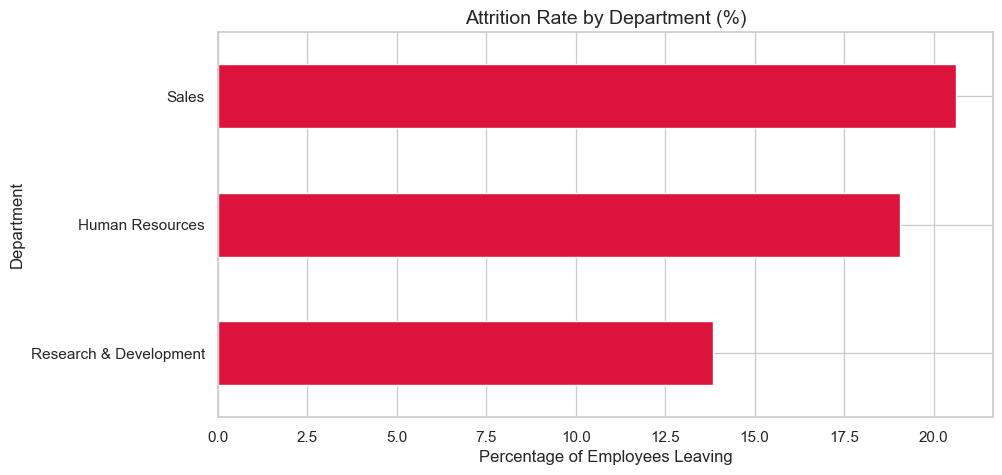

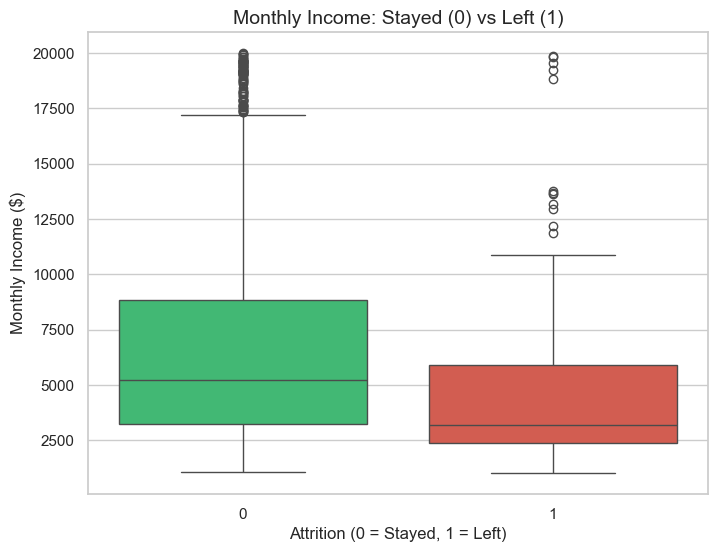

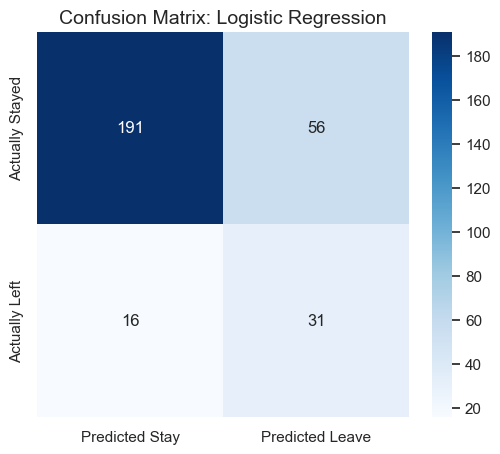

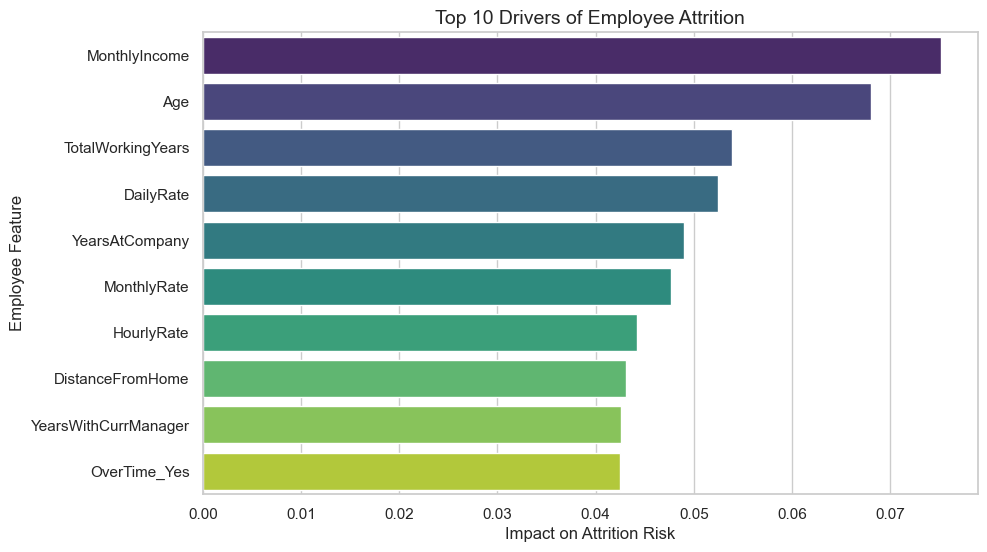

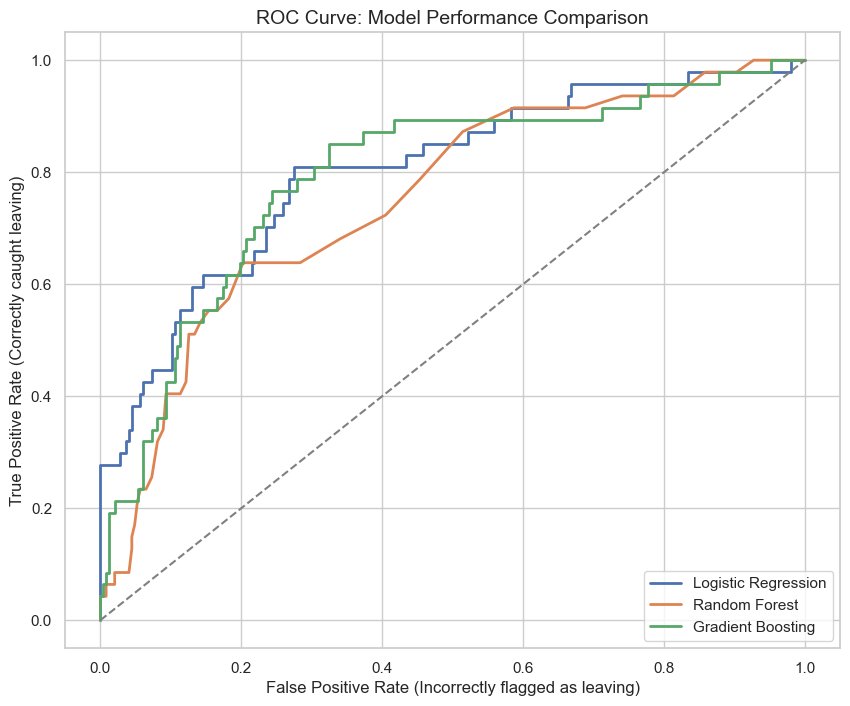

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
dept_counts = df_cleaned.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100
dept_counts[1].sort_values().plot(kind='barh', color='crimson')
plt.title('Attrition Rate by Department (%)', fontsize=14)
plt.xlabel('Percentage of Employees Leaving')
plt.ylabel('Department')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x='Attrition', y='MonthlyIncome', hue='Attrition', data=df_cleaned, palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Monthly Income: Stayed (0) vs Left (1)', fontsize=14)
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Monthly Income ($)')
plt.show()

plt.figure(figsize=(6, 5))
best_model = trained_models['Logistic Regression']
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Stay', 'Predicted Leave'], 
            yticklabels=['Actually Stayed', 'Actually Left'])
plt.title('Confusion Matrix: Logistic Regression', fontsize=14)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importance_df.head(10), palette='viridis', legend=False)
plt.title('Top 10 Drivers of Employee Attrition', fontsize=14)
plt.xlabel('Impact on Attrition Risk')
plt.ylabel('Employee Feature')
plt.show()

plt.figure(figsize=(10, 8))
for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name}')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve: Model Performance Comparison', fontsize=14)
plt.xlabel('False Positive Rate (Incorrectly flagged as leaving)')
plt.ylabel('True Positive Rate (Correctly caught leaving)')
plt.legend(loc="lower right")
plt.show()

### Task 7: Executive HR Summary & Recommendations

**Top Attrition Drivers:** The three factors that most strongly predict an employee will leave are Monthly Income, OverTime, and Age. 

**Areas of Immediate Focus:** HR should immediately prioritize retention efforts within the **Sales Department**, specifically targeting **Sales Representatives**, as they exhibit the **highest flight risk** across the company. 

**The Salary Question:** Salary alone does not explain attrition. While Monthly Income is the strongest predictor, OverTime and poor Work-Life Balance ratings are also massive drivers. This indicates a lethal combination of **burnout** rather than just compensation issues alone.

**Actionable HR Recommendations:**
1. **Targeted Sales Interventions:** Implement a mandatory check-in for all new Sales Representatives to review workload, adjust territories, and ensure adequate training, as early-tenure sales roles are the most vulnerable.
2. **Overtime & Burnout Audit:** Create a hard cap on allowable OverTime for lower-income brackets, or mandate immediate compensation/bonus reviews for employees who frequently log high overtime hours to offset burnout.

**Model Limitations:** The HR team should be aware that this model relies on a relatively small, imbalanced dataset (1,470 employees). Furthermore, AI cannot measure unquantifiable human elements—such as a toxic relationship with a direct manager or personal family circumstances—meaning this tool should be used as limited, not to make automated HR decisions.